In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve)

# Load clean data
df = pd.read_csv("../data/myopia_model_ready.csv")

# Define features and target
X = df.drop('MYOPIC', axis=1)
y = df['MYOPIC']

print("DATASET:")
print(f"Total patients: {len(df)}")
print(f"Features: {X.shape[1]}")
print(f"Myopic: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Not Myopic: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"\nFeatures used:")
print(X.columns.tolist())

DATASET:
Total patients: 618
Features: 15
Myopic: 81 (13.1%)
Not Myopic: 537 (86.9%)

Features used:
['AGE', 'GENDER', 'SPHEQ', 'AL', 'ACD', 'LT', 'VCD', 'SPORTHR', 'READHR', 'COMPHR', 'STUDYHR', 'TVHR', 'DIOPTERHR', 'MOMMY', 'DADMY']


In [2]:
# ============================================
# SPLIT DATA
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("SPLIT RESULTS:")
print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set:  {X_test.shape[0]} patients")
print(f"Myopic in training: {y_train.sum()}")
print(f"Myopic in testing:  {y_test.sum()}")

# ============================================
# SCALE DATA
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nData scaled successfully!")

# ============================================
# TRAIN LOGISTIC REGRESSION
# ============================================
model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
model.fit(X_train_scaled, y_train)
print("Logistic Regression trained successfully!")

# ============================================
# FEATURE COEFFICIENTS
# ============================================
print("\nFEATURE COEFFICIENTS:")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)
print(coef_df)

SPLIT RESULTS:
Training set: 494 patients
Testing set:  124 patients
Myopic in training: 65
Myopic in testing:  16

Data scaled successfully!
Logistic Regression trained successfully!

FEATURE COEFFICIENTS:
      Feature  Coefficient
14      DADMY     0.400605
13      MOMMY     0.342739
4         ACD     0.225164
1      GENDER     0.135598
8      READHR     0.083578
9      COMPHR     0.052406
12  DIOPTERHR    -0.039430
10    STUDYHR    -0.110051
3          AL    -0.166388
11       TVHR    -0.173054
6         VCD    -0.199675
5          LT    -0.227136
0         AGE    -0.253282
7     SPORTHR    -0.354575
2       SPHEQ    -2.546722


LOGISTIC REGRESSION RESULTS:
Accuracy:  0.8226
ROC AUC:   0.8258

Classification Report:
              precision    recall  f1-score   support

  Not Myopic       0.93      0.86      0.89       108
      Myopic       0.38      0.56      0.45        16

    accuracy                           0.82       124
   macro avg       0.65      0.71      0.67       124
weighted avg       0.86      0.82      0.84       124



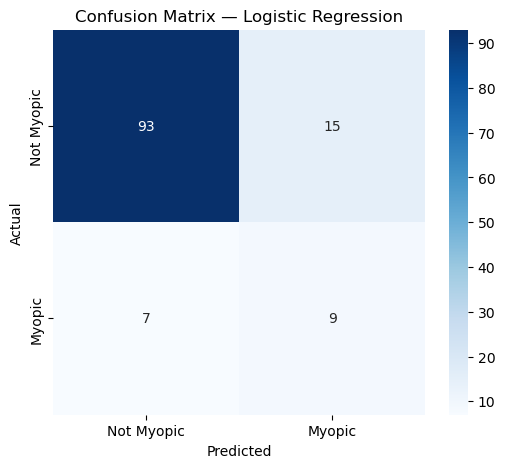

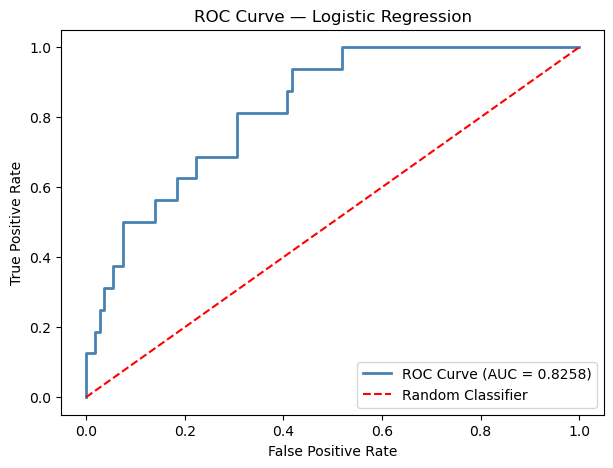


Results saved for final comparison:
{'Model': 'Logistic Regression', 'Accuracy': 0.8226, 'ROC_AUC': 0.8258}


In [3]:
# ============================================
# MAKE PREDICTIONS
# ============================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ============================================
# EVALUATION METRICS
# ============================================
print("LOGISTIC REGRESSION RESULTS:")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Myopic', 'Myopic']))

# ============================================
# CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Myopic', 'Myopic'],
            yticklabels=['Not Myopic', 'Myopic'])
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================
# ROC CURVE
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue',
         linewidth=2,
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red',
         linestyle='--', label='Random Classifier')
plt.title("ROC Curve — Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================
# SAVE RESULTS
# ============================================
lr_results = {
    'Model': 'Logistic Regression',
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_prob), 4)
}
print("\nResults saved for final comparison:")
print(lr_results)